# <center> Machine Learning in Computational Biology - Term Project </center>

## <center> Task B.5 </center>

### <center> Explainability & Error Analysis - Selected LOPO Pipelines </center>


## Libraries  &  Paths

In [1]:
import gc
import pickle
import random
import sys
import warnings
warnings.filterwarnings("ignore")
################################################################################################

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import shap
from scipy.stats import spearmanr
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay,average_precision_score,
                             confusion_matrix,precision_recall_curve,roc_auc_score,roc_curve)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

################################################################################################
SRC_DIR = Path("../src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from helper_functions import make_sample_balanced_class_weights # Task B4 referenced
from feature_builders import MIBuilder, PathwaysBuilder

################################################################################################
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

################################################################################################
# Task B4 referenced
MI_K = 500
TOP_N_FEATURES = 15
N_DEPENDENCE_PLOTS = 6
STABLE_GENE_FREQUENCY = 0.75 # Choice--> Genes selected in at least 75% of the LOPO folds are considered stable.

# Subsampling , why? it keeps SHAP computation manageable without changing the fitted models.
MAX_SHAP_CELLS_PER_FOLD = 150
MAX_BACKGROUND_CELLS = 200
MAX_PLOT_POINTS_PER_FEATURE = 2500

################################################################################################
OUTPUT_DIR = Path("../outputs")
FIGURES_DIR = Path("../figures")
TASKB5_OUTPUT_DIR = OUTPUT_DIR / "task_b5_explainability"
TASKB5_FIGURES_DIR = FIGURES_DIR / "task_b5_explainability"
TASKB5_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TASKB5_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
H5AD_FILE = OUTPUT_DIR / "filtered_anndata_pathways.h5ad"
################################################################################################

print("Input:", H5AD_FILE)
print("Task B.5 outputs:", TASKB5_OUTPUT_DIR)

Input: ..\outputs\filtered_anndata_pathways.h5ad
Task B.5 outputs: ..\outputs\task_b5_explainability


## Load the AnnData and Define the Preselected Pipelines


In [2]:
adata = sc.read_h5ad(H5AD_FILE)
pathway_cols = [str(column) for column in adata.obs.columns if str(column).lower().startswith("progeny_")]

# Metadata required for the LOPO explainability analysis.
required_obs = {"patient_id","patient_timepoint","response"}

missing_obs = required_obs - set(adata.obs.columns)
if missing_obs:
    raise KeyError(f"AnnData is missing required metadata columns: {sorted(missing_obs)}")

# Sanity check: Is the prediction target still binary ?
if not set(adata.obs["response"].dropna().unique()).issubset({0, 1}):
    raise ValueError("The response target must contain only 0 and 1.")

print("AnnData shape:", adata.shape)
print("Patients :", adata.obs["patient_id"].nunique())
print("Samples :", adata.obs["patient_timepoint"].nunique())
print("Pathways :", len(pathway_cols))

AnnData shape: (16291, 10019)
Patients : 32
Samples : 48
Pathways : 14


In [3]:
# Pipelines selected from the completed Task B.4 LOPO comparison.
# They are fixed before SHAP analysis and are not selected again in Task B.5.

BEST_PATHWAY_CONDITION = "B_Pathways"
BEST_PATHWAY_MODEL = "LogisticRegression"

BEST_GENE_CONDITION = "F_MI_Genes"
BEST_GENE_MODEL = "RandomForest"

print("Selected pathway pipeline:")
print(f" {BEST_PATHWAY_CONDITION} + {BEST_PATHWAY_MODEL}")

print("\nSelected gene pipeline:")
print(f" {BEST_GENE_CONDITION} + {BEST_GENE_MODEL}")

Selected pathway pipeline:
 B_Pathways + LogisticRegression

Selected gene pipeline:
 F_MI_Genes + RandomForest


**Why did we choose these models?**

The pathway model was the best overall pipeline in Task B.4 and uses the 14 PROGENy pathway scores directly and the gene model uses the MI-selected gene representation with Random Forest, allowing gene-level interpretation in a reduced feature space instead of using all 10,019 genes.

Regarding `F_MI_Genes`, feature selection is repeated independently within each LOPO training fold, using the same procedure and fixed settings as in Task B.4. Therefore, the selected genes can differ between LOPO folds without introducing data leakage.

For this reason, the gene-level interpretation considers both **SHAP importance** and **selection stability across folds**.


## Re-run the Two Selected Pipelines for SHAP

**Why is the re-run needed?** In Task B.4, the LOPO models were evaluated and their predictions and performance metrics were saved, but the fitted model from each LOPO fold was not kept.

For SHAP, we need these fitted models together with the exact features and transformed held-out data used in each fold. Therefore, the two selected pipelines are re-run using the same LOPO procedure, preprocessing, seed and weighting as in Task B.4.

**Note:** The results does not change from the previously reported Task B.4 results or perform any new model selection, the re-run is only performed for explainability.

In [4]:
# Creating the modelling arrays
X_genes = adata.X

if sp.issparse(X_genes):
    X_genes = X_genes.tocsr().astype(np.float32)
else:
    X_genes = np.asarray(X_genes, dtype=np.float32)


X_pathways = (adata.obs[pathway_cols].to_numpy(dtype=np.float32))
y = adata.obs["response"].to_numpy(dtype=np.int8)
groups = (adata.obs["patient_id"].astype(str).to_numpy())
sample_ids = (adata.obs["patient_timepoint"].astype(str).to_numpy())
gene_names = np.asarray(adata.var_names.astype(str))

print("Modelling arrays created.")
print(f"Cells: {len(y):,}")
print(f"Patients: {len(np.unique(groups))}")
print(f"Samples: {len(np.unique(sample_ids))}")

Modelling arrays created.
Cells: 16,291
Patients: 32
Samples: 48


In [5]:
# Selecting feature conditions and fixed models
# Specifically the two that was previously mentions and are mentioned herer.
# A fresh feature builder is created inside each LOPO fold.
CONDITIONS = {"B_Pathways": lambda: PathwaysBuilder(),
              "F_MI_Genes": lambda: MIBuilder(k=MI_K,add_pathways=False),}

# Same fixed model parameters used in Task B.4.
MODEL_PARAMS = {"LogisticRegression": {"penalty": "l2","solver": "lbfgs","max_iter": 1000,"class_weight": None,"random_state": SEED},
                "RandomForest": {"n_estimators": 100,"max_depth": 9,"min_samples_split": 5,"class_weight": None,"random_state": SEED,
                                 "n_jobs": -1}}


def build_fixed_model(model_name):
    if model_name not in MODEL_PARAMS:
        raise ValueError( f"Unknown model_name: {model_name}. Available models: {list(MODEL_PARAMS)}")

    params = MODEL_PARAMS[model_name].copy()

    if model_name == "LogisticRegression":
        return LogisticRegression(**params)
    if model_name == "RandomForest":
        return RandomForestClassifier(**params)
    raise ValueError(f"Unsupported model: {model_name}")


print("Task B.5 conditions and fixed models are ready.")

Task B.5 conditions and fixed models are ready.


In [6]:
# Re-running one condition-model pair using the same LOPO procedure as Task B.4, 
# while keeping the fitted objects and held-out data needed for SHAP.

def run_condition_with_artifacts(condition_name,model_name,X_genes,X_pathways,y,
                                 groups,sample_ids,gene_names,pathway_cols):
   

    groups_array = np.asarray(groups).astype(str)
    sample_ids_array = np.asarray(sample_ids).astype(str)
    y_array = np.asarray(y, dtype=int)

    logo = LeaveOneGroupOut()
    splits = list(logo.split(X=np.zeros(len(y_array)),y=y_array,groups=groups_array))

    fold_artifacts = {}
    sample_rows = []

    for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
        held_out_patient = np.unique(groups_array[test_idx])[0]
        train_sample_ids = sample_ids_array[train_idx]
        test_sample_ids = sample_ids_array[test_idx]
        y_train = y_array[train_idx]
        y_test = y_array[test_idx]

        # Createing and fitting a fresh feature builder inside the current LOPO fold.
        builder = CONDITIONS[condition_name]()
        builder.fit(genes=X_genes[train_idx],pathways=X_pathways[train_idx],y=y_train,group_ids=train_sample_ids,)

        X_train = builder.transform(genes=X_genes[train_idx],pathways=X_pathways[train_idx])
        X_test = builder.transform( genes=X_genes[test_idx],pathways=X_pathways[test_idx])

        feature_names = builder.get_feature_names(gene_names=gene_names,pathway_names=pathway_cols)

        # Using the same fold-specific scaling procedure as in Task B.4.
        if sp.issparse(X_train):
            scaler = StandardScaler(with_mean=False)
        else:
            scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Using the same sample-balanced training weights as in Task B.4.
        training_weights = make_sample_balanced_class_weights(train_sample_ids,y_train)

        model = build_fixed_model(model_name)
        model.fit(X_train_scaled,y_train,sample_weight=training_weights)

        # Predicting using the same transformed representation used in Task B.4.
        cell_probs = model.predict_proba(X_test_scaled)[:, 1]

        # D ense held-out matrix --> SHAP seems to works more conveniently
        if sp.issparse(X_test_scaled):
            X_test_for_shap = X_test_scaled.toarray()
        else:
            X_test_for_shap = np.asarray(X_test_scaled)

        # Aggregating held-out cell probabilities to biological-sample scores.
        for current_sample in np.sort(pd.unique(test_sample_ids)):
            sample_mask = test_sample_ids == current_sample
            labels_in_sample = np.unique(y_test[sample_mask])

            if len(labels_in_sample) != 1:
                raise ValueError(f"Sample {current_sample} has multiple response labels:{labels_in_sample}")

            sample_rows.append({"sample_id": str(current_sample),
                                "patient_id": held_out_patient,
                                "true_label": int(labels_in_sample[0]),
                                "sample_score": float(cell_probs[sample_mask].mean())} )

        # Keeping only the objects needed later for SHAP.
        fold_artifacts[fold_number] = {"model": model,
                                       "scaler": scaler,
                                       "feature_names": feature_names,
                                       "Xte_transformed": X_test_for_shap,
                                       "test_idx": test_idx,
                                       "test_sample_ids": test_sample_ids,
                                       "cell_probs": cell_probs,
                                       "held_patient": held_out_patient}

        del X_train, X_test, X_train_scaled, X_test_scaled
        gc.collect()

        print(f"{condition_name} | {model_name} | fold {fold_number}/{len(splits)} done (held out {held_out_patient})")

    sample_results = pd.DataFrame(sample_rows)

    return {"condition": condition_name,
            "model_name": model_name,
            "metrics": {"Primary_Sample_AUC_All": roc_auc_score(sample_results["true_label"],sample_results["sample_score"] )},
            "fold_artifacts": fold_artifacts,
            "sample_results": sample_results}

In [7]:
# Re-running the two selected Task B.4 pipelines

print("Re-running selected PATHWAY pipeline...")

pathway_bundle = run_condition_with_artifacts(BEST_PATHWAY_CONDITION,BEST_PATHWAY_MODEL,
                                            X_genes,X_pathways, y,groups,sample_ids,
                                            gene_names,pathway_cols)

print("\nRe-running selected GENE pipeline...")

gene_bundle = run_condition_with_artifacts(BEST_GENE_CONDITION,BEST_GENE_MODEL,X_genes,
                                           X_pathways,y,groups,sample_ids,gene_names,pathway_cols)


# Saving the rerun objects so SHAP.
with open(TASKB5_OUTPUT_DIR / "taskB5_pathway_bundle.pkl", "wb") as file: pickle.dump(pathway_bundle, file)
with open(TASKB5_OUTPUT_DIR / "taskB5_gene_bundle.pkl","wb") as file: pickle.dump(gene_bundle, file)
print("\nSaved pathway and gene bundles for SHAP reuse.")

Re-running selected PATHWAY pipeline...
B_Pathways | LogisticRegression | fold 1/32 done (held out P1)
B_Pathways | LogisticRegression | fold 2/32 done (held out P10)
B_Pathways | LogisticRegression | fold 3/32 done (held out P11)
B_Pathways | LogisticRegression | fold 4/32 done (held out P12)
B_Pathways | LogisticRegression | fold 5/32 done (held out P13)
B_Pathways | LogisticRegression | fold 6/32 done (held out P14)
B_Pathways | LogisticRegression | fold 7/32 done (held out P15)
B_Pathways | LogisticRegression | fold 8/32 done (held out P16)
B_Pathways | LogisticRegression | fold 9/32 done (held out P17)
B_Pathways | LogisticRegression | fold 10/32 done (held out P18)
B_Pathways | LogisticRegression | fold 11/32 done (held out P19)
B_Pathways | LogisticRegression | fold 12/32 done (held out P2)
B_Pathways | LogisticRegression | fold 13/32 done (held out P20)
B_Pathways | LogisticRegression | fold 14/32 done (held out P21)
B_Pathways | LogisticRegression | fold 15/32 done (held out P

## Reproducibility check against Task B.4

In [8]:
B4_RESULTS_DIR = OUTPUT_DIR / "task_b_lopo_no_tuning"
B4_SUMMARY_FILE = (B4_RESULTS_DIR/ "taskb_shared_preprocessing_patient_score_fixed_v6_ablation_summary.csv")

b4_summary = pd.read_csv(B4_SUMMARY_FILE, index_col=["Model", "Condition"])

rerun_checks = [{"model": BEST_PATHWAY_MODEL,
                 "condition": BEST_PATHWAY_CONDITION,
                 "rerun_auc": pathway_bundle["metrics"]["Primary_Sample_AUC_All"]},
                {"model": BEST_GENE_MODEL,
                 "condition": BEST_GENE_CONDITION,
                 "rerun_auc": gene_bundle["metrics"]["Primary_Sample_AUC_All"]}]

reproducibility_rows = []

for check in rerun_checks:
    model_name = check["model"]
    condition_name = check["condition"]
    rerun_auc = check["rerun_auc"]

    b4_auc = b4_summary.loc[(model_name, condition_name),"Primary_Sample_AUC_All",]
    auc_difference = abs(rerun_auc - b4_auc)
    reproducibility_rows.append({"Model": model_name,"Condition": condition_name,
                                 "Task_B4_AUC": b4_auc, "Task_B5_Rerun_AUC": rerun_auc,
                                 "Absolute_difference": auc_difference})

reproducibility_df = pd.DataFrame(reproducibility_rows)
display(reproducibility_df)

# With this rerun, the resilts up to numerical precision from Task B.4 are reproduced.
AUC_TOLERANCE = 1e-10

if (reproducibility_df["Absolute_difference"] > AUC_TOLERANCE).any():
    raise ValueError("The Task B.5 rerun does not reproduce the Task B.4 AUC results.")

print("Reproducibility check passed: Task B.5 reruns reproduce the Task B.4 AUC results.")

,Model,Condition,Task_B4_AUC,Task_B5_Rerun_AUC,Absolute_difference
0,LogisticRegression,B_Pathways,0.876660,0.876660,0.0
1,RandomForest,F_MI_Genes,0.834915,0.834915,0.0


Reproducibility check passed: Task B.5 reruns reproduce the Task B.4 AUC results.


## Reconstruct Sample- and Cell-Level Prediction Tables

The LOPO re-run predictions are organized into sample-level and cell-level tables, where tables will be used in the following SHAP and error-analysis steps.

Regarding the sample-level predictions, they represent the main biological-sample evaluation used in Task B.4, while the cell-level probabilities are kept to examine how the model behaves within each held-out sample.

In [9]:
def reconstruct_prediction_tables(bundle, tag):

    sample_results = bundle["sample_results"].copy()
    sample_results["sample_id"] = (sample_results["sample_id"].astype(str))
    sample_results["patient_id"] = (sample_results["patient_id"].astype(str))
    sample_results["true_label"] = (sample_results["true_label"].astype(int))
    sample_results["sample_score"] = (sample_results["sample_score"].astype(float))

    # Converting sample-level probabilities to class predictions using the same fixed threshold used in Task B.4.
    sample_results["y_pred"] = (sample_results["sample_score"] >= 0.5).astype(int)
    sample_results["correct"] = (sample_results["y_pred"] == sample_results["true_label"])
    sample_results["error_type"] = np.select([((sample_results["true_label"] == 0) & (sample_results["y_pred"] == 1)),
                                              ((sample_results["true_label"] == 1) & (sample_results["y_pred"] == 0))],
                                              ["False positive","False negative"],
                                              default="Correct")

    # Distance from the 0.5 decision threshold.
    sample_results["confidence_margin"] = np.abs(sample_results["sample_score"] - 0.5)

    # The Maps are used to assign sample/patient labels back to each held-out cell.
    sample_label_map = (sample_results.set_index("sample_id")["true_label"].to_dict())
    sample_patient_map = (sample_results.set_index("sample_id")["patient_id"].to_dict())

    cell_frames = []

    for fold, artifact in bundle["fold_artifacts"].items():

        sample_ids_fold = np.asarray(artifact["test_sample_ids"]).astype(str)
        probabilities = np.asarray(artifact["cell_probs"],dtype=float)

        cell_frames.append(pd.DataFrame({"fold": int(fold),
                                         "patient_id": [sample_patient_map[s] for s in sample_ids_fold],
                                         "sample_id": sample_ids_fold,
                                         "true_label": [ sample_label_map[s] for s in sample_ids_fold],
                                         "cell_probability": probabilities,
                                         "cell_pred": (probabilities >= 0.5).astype(int)}))

    cell_predictions = pd.concat(cell_frames,ignore_index=True)

    # Adding the number of cells contributing to each biological sample.
    if "n_cells" not in sample_results.columns:
        cell_counts = (cell_predictions.groupby("sample_id").size().rename("n_cells"))
        sample_results = sample_results.merge(cell_counts,on="sample_id",how="left")


    sample_results.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_sample_predictions.csv",index=False)
    cell_predictions.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_cell_predictions.csv",index=False)

    print(f"{tag.title()} cell-level predictions: {cell_predictions.shape}")
    print(f"{tag.title()} sample-level predictions: {sample_results.shape}")
    display(sample_results.head())

    return {"tag": tag,"sample_results": sample_results,"cell_predictions": cell_predictions,}


pathway_predictions = reconstruct_prediction_tables(pathway_bundle,"pathway")
gene_predictions = reconstruct_prediction_tables(gene_bundle,"gene")

Pathway cell-level predictions: (16291, 6)
Pathway sample-level predictions: (48, 9)


,sample_id,patient_id,true_label,sample_score,y_pred,correct,error_type,confidence_margin,n_cells
0,Post_P1,P1,1,0.504270,1,True,Correct,0.004270,291
1,Post_P1_2,P1,0,0.525224,1,False,False positive,0.025224,353
2,Pre_P1,P1,1,0.508174,1,True,Correct,0.008174,229
3,Post_P10,P10,0,0.331999,0,True,Correct,0.168001,396
4,Post_P11,P11,0,0.443536,0,True,Correct,0.056464,313


Gene cell-level predictions: (16291, 6)
Gene sample-level predictions: (48, 9)


,sample_id,patient_id,true_label,sample_score,y_pred,correct,error_type,confidence_margin,n_cells
0,Post_P1,P1,1,0.418251,0,False,False negative,0.081749,291
1,Post_P1_2,P1,0,0.409470,0,True,Correct,0.090530,353
2,Pre_P1,P1,1,0.452351,0,False,False negative,0.047649,229
3,Post_P10,P10,0,0.442828,0,True,Correct,0.057172,396
4,Post_P11,P11,0,0.522676,1,False,False positive,0.022676,313


## SHAP Global Importance - LOPO-Aware

- Feature importance is calculated separately within each LOPO fold using only the held-out cells of that fold.

- For the pathway model, the same 14 PROGENy pathways are present in every fold.

- For `F_MI_Genes`, MI feature selection is repeated independently within each training fold, so the selected genes can differ between folds.

- For the overall gene importance, a gene receives an importance of zero in folds where it was not selected. Conditional importance is also calculated as the mean importance only across the folds where that gene was selected.

> In this way, gene interpretation considers both the importance of a gene when it is selected and how consistently it is selected across the LOPO folds.

In [10]:
# SHAP helper functions

def balanced_indices(candidate_indices, group_values, max_n, rng):

    candidate_indices = np.asarray(candidate_indices, dtype=int)
    groups = np.asarray(group_values)[candidate_indices]

    if len(candidate_indices) <= max_n:
        return candidate_indices

    unique_groups = np.unique(groups)
    per_group = max(1, max_n // len(unique_groups))

    selected = []

    for group in unique_groups:
        group_idx = candidate_indices[groups == group ]
        n_take = min(per_group,len(group_idx))
        chosen = rng.choice(group_idx,size=n_take,replace=False)
        selected.extend(chosen.tolist())

    # Filling any remaining positions from unused training cells.
    if len(selected) < max_n:
        remaining = np.setdiff1d(candidate_indices,np.asarray(selected, dtype=int),assume_unique=False)
        n_extra = min( max_n - len(selected), len(remaining))

        if n_extra > 0:
            extra = rng.choice(remaining,size=n_extra,replace=False)
            selected.extend(extra.tolist())

    return np.asarray(selected[:max_n],dtype=int)


#################################################################################################
#Function retrieving raw features from AnnData using the feature names stored for the current LOPO fold.
def raw_feature_matrix(adata_obj, row_indices, feature_names):
    
    feature_names = list(feature_names)
    pathway_features = [feature for feature in feature_names if feature.startswith("PROGENy_")]
    gene_features = [feature for feature in feature_names if not feature.startswith("PROGENy_")]

    parts = []
    if gene_features:
        gene_matrix = adata_obj[ row_indices,gene_features].X

        if sp.issparse(gene_matrix):
            gene_matrix = gene_matrix.toarray()

        parts.append(np.asarray(gene_matrix,dtype=np.float32))

    if pathway_features:

        pathway_matrix = (adata_obj.obs.iloc[row_indices][pathway_features].to_numpy(dtype=np.float32))
        parts.append(pathway_matrix)

    if not parts:
        raise ValueError("No matching gene or pathway features were found.")

    if len(parts) == 1:
        return parts[0]

    return np.hstack(parts)


#################################################################################################
# Function returning SHAP values for the positive class in a consistent cells x features format.
def positive_class_shap_values(values):
   
    # Older SHAP versions may return one array per class.
    if isinstance(values, list):

        if len(values) == 2:
            return np.asarray(values[1])
        
        return np.asarray(values[0])

    values = np.asarray(values)

    # Some SHAP versions return cells x features x classes
    if values.ndim == 3:
        if values.shape[-1] == 2:
            return values[:, :, 1]

        if values.shape[0] == 2:
            return values[1]

    return values


In [11]:
# Defining native importance.
# This function is used only as a fallback when SHAP values
# cannot be calculated for a LOPO fold.
def native_importance(model, feature_names):

    if hasattr(model, "coef_"):
        values = np.abs(np.asarray(model.coef_)).reshape(-1)

    elif hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_,dtype=float)

    else:
        raise ValueError("The model does not provide native feature importance.")

    if len(values) != len(feature_names):
        raise ValueError("Native importance length does not match the number of feature names.")

    return pd.Series(values,index=feature_names,dtype=float)

In [12]:
# LOPO-aware SHAP analysis

def compute_explainability(bundle, tag):

    rng = np.random.default_rng(SEED)
    patient_values = (adata.obs["patient_id"].astype(str).to_numpy())
    all_row_indices = np.arange(adata.n_obs)
    all_folds = sorted(int(fold) for fold in bundle["fold_artifacts"])

    importance_rows = []
    fold_records = []
    method_counts = {}

    for fold_key, artifact in bundle["fold_artifacts"].items():
        fold = int(fold_key)
        model = artifact["model"]
        scaler = artifact["scaler"]
        feature_names = list(artifact["feature_names"])

        X_test = np.asarray(artifact["Xte_transformed"])

        sampled_test_idx = rng.choice(X_test.shape[0],
                                      size=min(MAX_SHAP_CELLS_PER_FOLD,X_test.shape[0]),
                                      replace=False)

        X_sample = X_test[sampled_test_idx]
        shap_values = None
        method = "native_importance"

        try:
            # Logistic Regression
            if hasattr(model, "coef_"):
                test_idx = np.asarray(artifact["test_idx"],dtype=int)
                train_idx = np.setdiff1d(all_row_indices,test_idx,assume_unique=False)

                # Background cells are selected only from the training patients of this fold.
                background_idx = balanced_indices( train_idx,patient_values,MAX_BACKGROUND_CELLS,rng)

                X_background_raw = raw_feature_matrix(adata,background_idx,feature_names)
                X_background = scaler.transform(X_background_raw)

                # SHAP internally subsamples the 200-cell background  to 100 samples.
                # This default behaviour is kept for consistency with the shap analysis that was first done
                # in the tuning analysis.
                explainer = shap.LinearExplainer(model,X_background)
                shap_values = positive_class_shap_values(explainer.shap_values(X_sample))
                method = "shap_linear_training_background"

            # Random Forest
            elif hasattr(model, "feature_importances_"):
                explainer = shap.TreeExplainer(model)
                shap_values = positive_class_shap_values(explainer.shap_values(X_sample))
                method = "shap_tree"

        except Exception as error:

            print(f"{tag}, fold {fold}: SHAP failed; using native importance. {type(error).__name__}: {error}")
            shap_values = None
            method = "native_importance"

        # Checking that the SHAP output has the expected cells x features structure.
        if shap_values is not None:
            shap_values = np.asarray(shap_values)
            if (shap_values.ndim != 2 or shap_values.shape[1] != len(feature_names)):
                print(f"{tag}, fold {fold}: unexpected SHAP shape {shap_values.shape}; using native importance.")
                shap_values = None
                method = "native_importance"

        # Feature importance.
        # Using model-native importance only if SHAP was unavailable for the current fold.(Useful)
        if shap_values is None:
            importance = native_importance(model,feature_names)
        else:
            importance = pd.Series( np.abs(shap_values).mean(axis=0),index=feature_names,dtype=float)
            fold_records.append({"fold": fold,"held_patient": str(artifact.get("held_patient",fold)),
                    "feature_names": feature_names,"X_sample": X_sample,"shap_values": shap_values})

        method_counts[method] = (method_counts.get(method, 0) + 1)

        for feature, value in importance.items():
            if pd.notna(value):
                importance_rows.append({"fold": fold,"feature": feature,"importance": float(value),"method": method})

 
    # Fold-level importance table
    importance_df = pd.DataFrame(importance_rows)
    importance_df.to_csv( TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_fold_feature_importance.csv",index=False)

    
    # Global LOPO importance
    wide = (importance_df.pivot_table( index="feature", columns="fold",
                                      values="importance",aggfunc="mean").reindex(columns=all_folds))


    # True -->  A feature was present in a particular fold.
    selected = wide.notna()

    # For the overall LOPO importance, features not selected in a fold receive an importance of zero.
    zero_filled = wide.fillna(0.0)

    summary = pd.DataFrame({"feature": wide.index,
                            "overall_mean_importance":zero_filled.mean(axis=1).to_numpy(),
                            "overall_std_importance":zero_filled.std(axis=1,ddof=1)
                            .fillna(0)
                            .to_numpy(),
                            # Importance only across folds where the feature was actually selected.
                            "conditional_mean_importance": wide.mean(axis=1,skipna=True).to_numpy(),
                            "n_folds_selected":selected.sum(axis=1).to_numpy(dtype=int),
                            "selection_frequency":selected.mean(axis=1).to_numpy()})

    summary["overall_sem_importance"] = (summary["overall_std_importance"] / np.sqrt(len(all_folds)))
    summary["feature_type"] = np.where(summary["feature"].str.startswith("PROGENy_"),"Pathway","Gene")
    summary = (summary.sort_values(["overall_mean_importance","selection_frequency"],
                                   ascending=[False,False]).reset_index(drop=True))
    summary.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_global_importance_lopo.csv",index=False)

    print(f"{tag}: methods={method_counts}; folds={len(all_folds)}; features={len(summary)}")
    display( summary.head(TOP_N_FEATURES))

    return {"tag": tag, "importance_df": importance_df, "summary": summary, 
            "fold_records": fold_records,"n_folds": len(all_folds),"method_counts": method_counts}

In [13]:
pathway_explanations = compute_explainability(pathway_bundle,"pathway")
gene_explanations = compute_explainability(gene_bundle,"gene")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP val

pathway: methods={'shap_linear_training_background': 32}; folds=32; features=14


,feature,overall_mean_importance,overall_std_importance,conditional_mean_importance,n_folds_selected,selection_frequency,overall_sem_importance,feature_type
0,PROGENy_JAK-STAT,0.432454,0.159042,0.432454,32,1.0,0.028115,Pathway
1,PROGENy_NFkB,0.271884,0.036143,0.271884,32,1.0,0.006389,Pathway
2,PROGENy_TNFa,0.253949,0.026489,0.253949,32,1.0,0.004683,Pathway
3,PROGENy_EGFR,0.215009,0.028067,0.215009,32,1.0,0.004962,Pathway
4,PROGENy_p53,0.196277,0.044517,0.196277,32,1.0,0.007870,Pathway
5,PROGENy_MAPK,0.190839,0.026041,0.190839,32,1.0,0.004603,Pathway
6,PROGENy_PI3K,0.160862,0.027480,0.160862,32,1.0,0.004858,Pathway
7,PROGENy_Estrogen,0.107276,0.020044,0.107276,32,1.0,0.003543,Pathway
8,PROGENy_TGFb,0.105772,0.015544,0.105772,32,1.0,0.002748,Pathway
9,PROGENy_Androgen,0.093722,0.011928,0.093722,32,1.0,0.002109,Pathway


gene: methods={'shap_tree': 32}; folds=32; features=1749


,feature,overall_mean_importance,overall_std_importance,conditional_mean_importance,n_folds_selected,selection_frequency,overall_sem_importance,feature_type
0,ANXA5,0.014914,0.003279,0.014914,32,1.00000,0.000580,Gene
1,PSME2,0.014867,0.004552,0.015859,30,0.93750,0.000805,Gene
2,MT2A,0.013785,0.004464,0.014704,30,0.93750,0.000789,Gene
3,TMSB10,0.009812,0.007916,0.015698,20,0.62500,0.001399,Gene
4,WARS,0.008699,0.002831,0.009279,30,0.93750,0.000501,Gene
5,APOBEC3C,0.008162,0.004860,0.010448,25,0.78125,0.000859,Gene
6,PGAM1,0.008009,0.004548,0.010251,25,0.78125,0.000804,Gene
7,GAPDH,0.006978,0.012315,0.027914,8,0.25000,0.002177,Gene
8,CLIC1,0.006604,0.005215,0.010063,21,0.65625,0.000922,Gene
9,APOL2,0.006029,0.003524,0.007717,25,0.78125,0.000623,Gene


**Comment:**

## Visualize Global Importance

In [14]:
def plot_global_importance(explanation_result):

    tag = explanation_result["tag"]
    summary = explanation_result["summary"]

    # Selecting the most important features and reverse their order 
    # so the highest-importance feature appears at the top.
    top = (summary.head(TOP_N_FEATURES).sort_values("overall_mean_importance"))

    # Global LOPO SHAP importance
    fig, ax = plt.subplots(figsize=( 8.5, max(5, 0.38 * len(top))))

    ax.barh( top["feature"],top["overall_mean_importance"],
            xerr=top["overall_sem_importance"],capsize=3,alpha=0.85,)
    ax.set_xlabel("Mean |SHAP| across all LOPO folds")
    ax.set_title(f"{tag.title()} global importance\n missing-fold importance = 0; error bars = SEM")
    ax.grid(axis="x",alpha=0.3)

    plt.tight_layout()
    plt.savefig(TASKB5_FIGURES_DIR/ f"taskB5_{tag}_global_importance.png",dpi=180,bbox_inches="tight")

    plt.show()


    # Gene importance vs. selection stability
    if tag == "gene":
        plot_df = summary.head(max(TOP_N_FEATURES, 25))

        fig, ax = plt.subplots(figsize=(7.5, 5.5))

        ax.scatter(plot_df["selection_frequency"],
                   plot_df["overall_mean_importance"],s=55,alpha=0.8)

        # Labeling only the top genes to keep for plot readability.
        for _, row in plot_df.head(TOP_N_FEATURES).iterrows():

            ax.text(row["selection_frequency"],row["overall_mean_importance"],row["feature"],fontsize=8)

        ax.axvline(STABLE_GENE_FREQUENCY,color="red",linestyle="--",linewidth=1,
                   label=(f"Stable threshold = {STABLE_GENE_FREQUENCY:.0%}"))
        ax.set_xlabel("Selection frequency across LOPO folds")
        ax.set_ylabel("Mean |SHAP| across all folds")
        ax.set_title("Gene importance versus selection stability")
        ax.legend()

        plt.tight_layout()
        plt.savefig( TASKB5_FIGURES_DIR/ "taskB5_gene_importance_vs_selection_frequency.png",
                    dpi=180,bbox_inches="tight")

        plt.show()

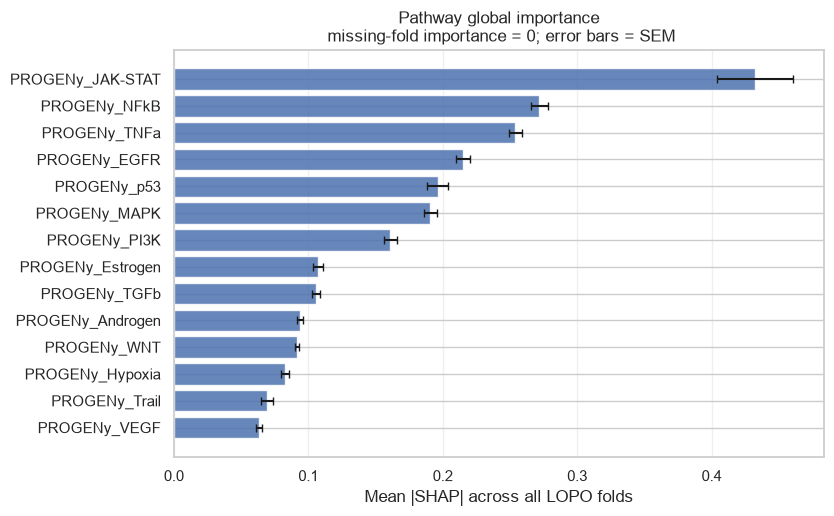

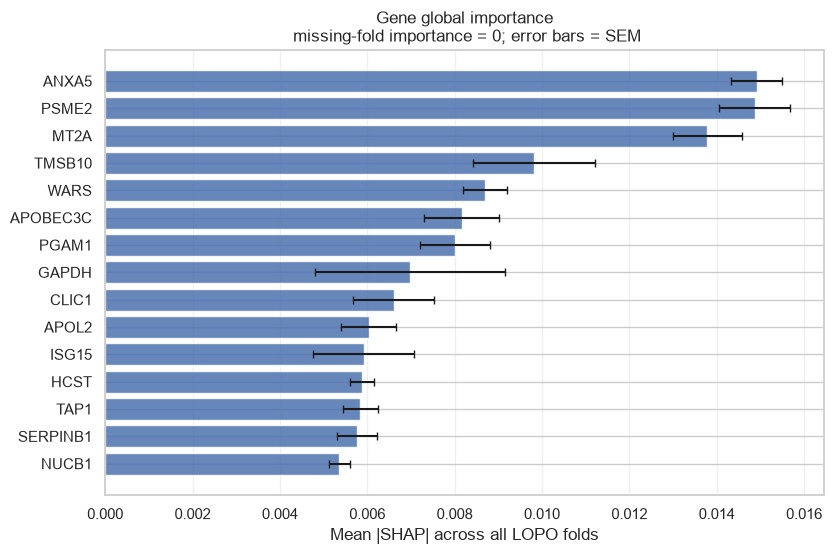

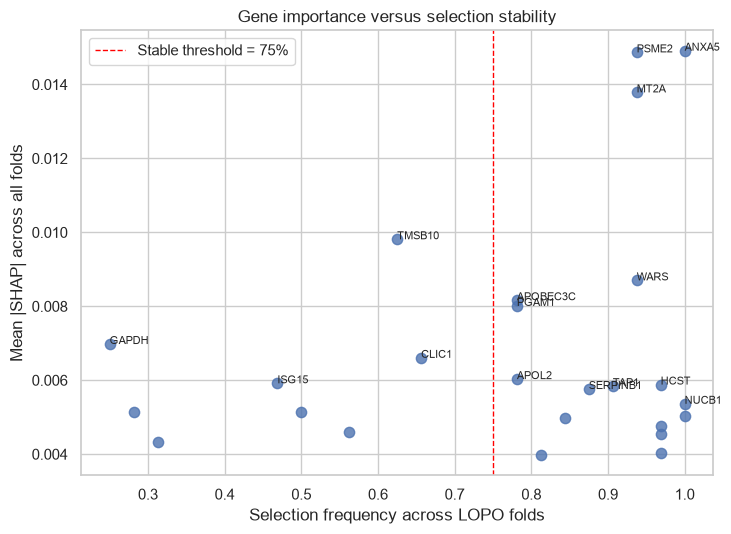

In [15]:
plot_global_importance(pathway_explanations)
plot_global_importance(gene_explanations)

## SHAP Directionality (Beeswarm-Like)

In [16]:
def collect_feature_points(explanation_result, features):

    rows = []
    feature_set = set(features)

    for record in explanation_result["fold_records"]:
        positions = {feature: record["feature_names"].index(feature)
                      for feature in feature_set
                      if feature in record["feature_names"]}

        for feature, position in positions.items():
            for x_value, shap_value in zip(record["X_sample"][:, position],record["shap_values"][:, position]):
                rows.append({"feature": feature,"feature_value_scaled": float(x_value),
                             "shap_value": float(shap_value),"fold": record["fold"]})

    return pd.DataFrame(rows)


#########################################################################################################################
def plot_beeswarm_like(explanation_result):

    tag = explanation_result["tag"]
    top_features = (explanation_result["summary"].head(TOP_N_FEATURES)["feature"].tolist())

    points = collect_feature_points(explanation_result,top_features)
    points.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_top_feature_shap_points.csv",index=False)

    if points.empty:
        print( f"{tag}: no SHAP values available for directionality plot.")
        return points

    rng = np.random.default_rng(SEED)

    pieces = []

    # Limiting the number of plotted points per feature to keep the figure readable.
    for feature, group in points.groupby("feature"):

        if len(group) > MAX_PLOT_POINTS_PER_FEATURE:
            group = group.sample(MAX_PLOT_POINTS_PER_FEATURE,random_state=SEED)

        pieces.append(group)

    plot_df = pd.concat(pieces,ignore_index=True)

    # Reversing the order so the highest-rankedfeature appears at the top.
    order = list(reversed(top_features))
    y_lookup = {feature: i for i, feature in enumerate(order)}
    y_values = (plot_df["feature"].map(y_lookup).to_numpy(dtype=float))

    # Adding small vertical jitter to reduce point overlap.
    y_values += rng.normal(0, 0.10, size=len(y_values))
    color_values = (plot_df["feature_value_scaled"].clip(-2.5, 2.5))

    norm = Normalize(vmin=-2.5,vmax=2.5)

    fig, ax = plt.subplots(figsize=(9, max(5.5, 0.38 * len(order))))

    scatter = ax.scatter(plot_df["shap_value"],y_values,c=color_values,
                         cmap="coolwarm",norm=norm,s=9,alpha=0.55,linewidth=0)
    ax.axvline(0,color="black",linestyle="--",linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("SHAP value (positive -> responder prediction)")
    ax.set_title(f"{tag.title()} SHAP directionality on held-out cells")

    fig.colorbar(scatter,ax=ax,pad=0.02).set_label("Fold-standardized feature value")

    plt.tight_layout()
    plt.savefig(TASKB5_FIGURES_DIR/ f"taskB5_{tag}_shap_directionality.png",dpi=180,bbox_inches="tight")
    plt.show()

    return points

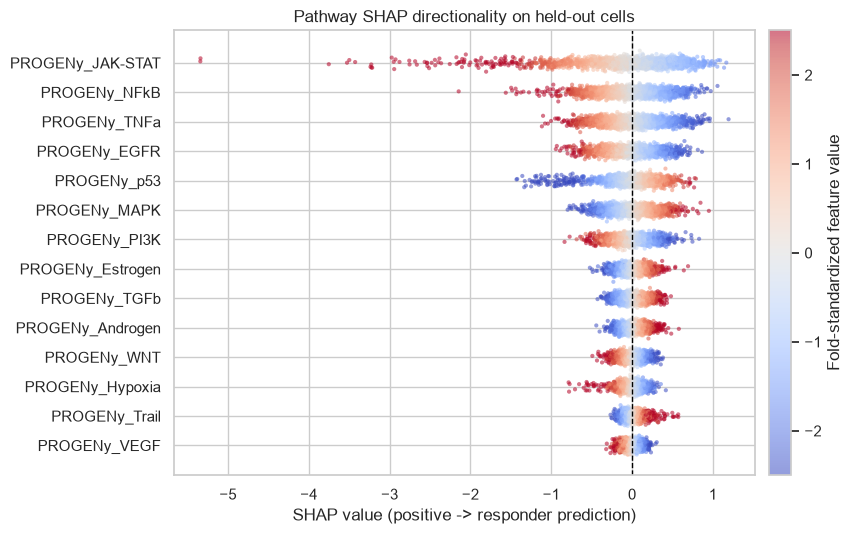

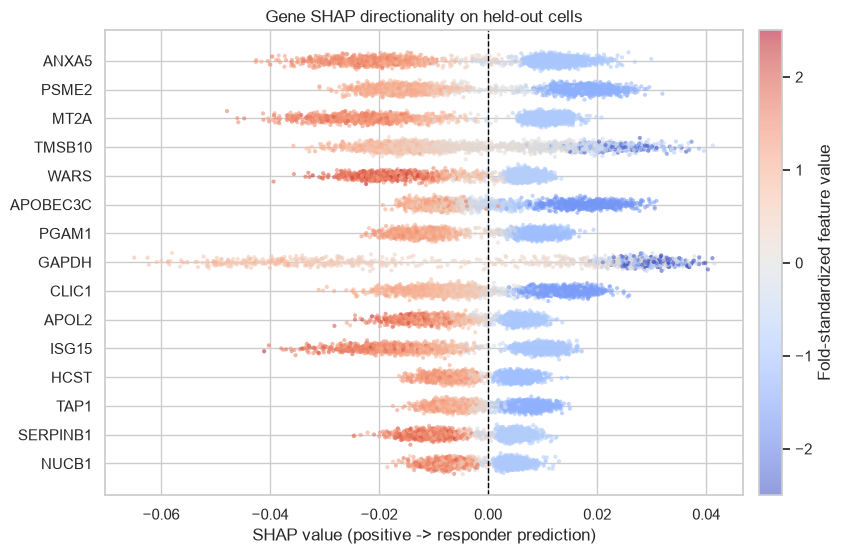

In [17]:
pathway_shap_points = plot_beeswarm_like(pathway_explanations)
gene_shap_points = plot_beeswarm_like( gene_explanations)

## SHAP Dependence Plots (Top Features)

In [18]:
def dependence_and_direction_summary(explanation_result, points):

    tag = explanation_result["tag"]
    summary = explanation_result["summary"]

    # For genes --> Only sufficiently stable features.
    # For pathways --> All pathway features are eligible.
    if tag == "gene":
        candidates = summary[summary["selection_frequency"] >= STABLE_GENE_FREQUENCY]
    else:
        candidates = summary

    features = (candidates.head(N_DEPENDENCE_PLOTS)["feature"].tolist())

    direction_rows = []

    for feature in features:
        data = points[ points["feature"] == feature].copy()

        # Just to be sure: Reconstructing the SHAP points if they were not already included in the stored top-feature point table.
        if data.empty:
            data = collect_feature_points(explanation_result,[feature])

        if data.empty:
            continue

        # Spearman correlation is used only as a descriptive summary of the feature-SHAP relationship.
        rho, p_value = spearmanr(data["feature_value_scaled"],data["shap_value"])

        if rho > 0.05:
            direction = ("Higher value tends toward responder prediction")
        elif rho < -0.05:
            direction = ("Higher value tends toward non-responder prediction")
        else:
            direction = ("Weak or non-monotonic direction")

        direction_rows.append({"feature": feature,
                               "spearman_rho_feature_vs_shap": float(rho),
                               "p_value_descriptive_only": float(p_value),
                               "direction": direction,
                               "n_points": len(data),
                               "n_folds_with_shap": data["fold"].nunique()})

        
        # SHAP dependence plot
        fig, ax = plt.subplots(figsize=(6.8, 4.8))

        ax.scatter( data["feature_value_scaled"], data["shap_value"],s=14,alpha=0.35,linewidth=0)

        # Adding a quantile-binned trend line to make the overall direction easier to interpret.
        try:
            data["bin"] = pd.qcut(data["feature_value_scaled"],q=12,duplicates="drop")

            trend = (data.groupby("bin",observed=True).agg(x=("feature_value_scaled", "mean"),
                                                           y=("shap_value", "mean")))
            ax.plot(trend["x"],trend["y"],color="black",marker="o",
                    linewidth=2,markersize=4,label="Quantile-binned mean")
            ax.legend(fontsize=8)

        except Exception:
            pass

        ax.axhline(0,color="black",linestyle="--",linewidth=1)
        ax.set_xlabel(f"{feature} value (fold-standardized)")
        ax.set_ylabel(f"SHAP value for {feature}")
        ax.set_title(f"SHAP dependence: {feature}\n {data['fold'].nunique()} LOPO folds represented")
        plt.tight_layout()

        safe_feature = "".join(character if character.isalnum() or character in "-_" else "_"for character in feature)

        plt.savefig(TASKB5_FIGURES_DIR/ f"taskB5_{tag}_dependence_{safe_feature}.png",dpi=180,bbox_inches="tight",)
        plt.show()

    direction_df = pd.DataFrame(direction_rows)
    direction_df.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_directionality_summary.csv",index=False,)
    display(direction_df)

    return direction_df

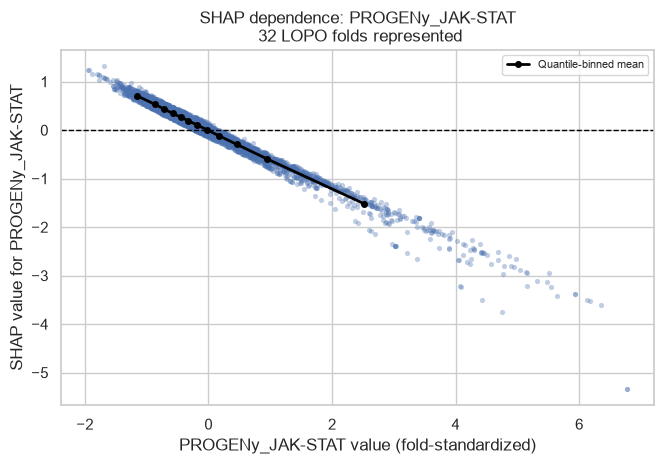

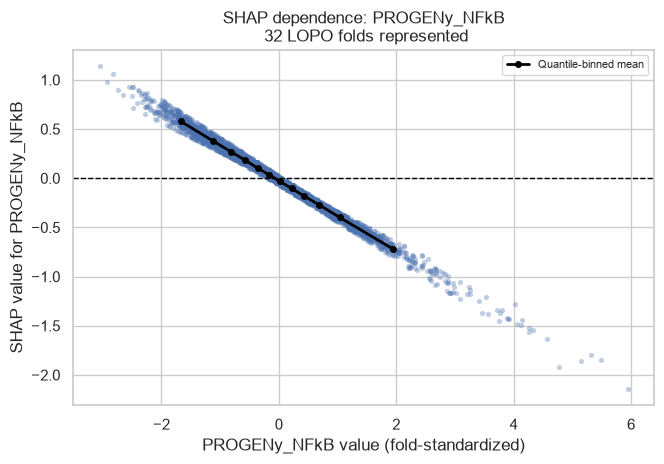

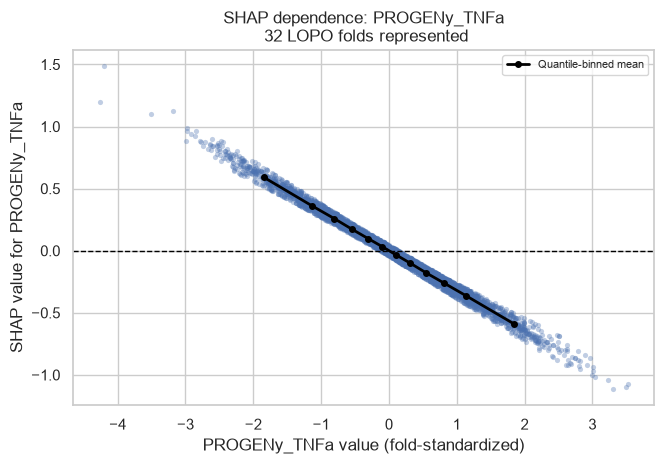

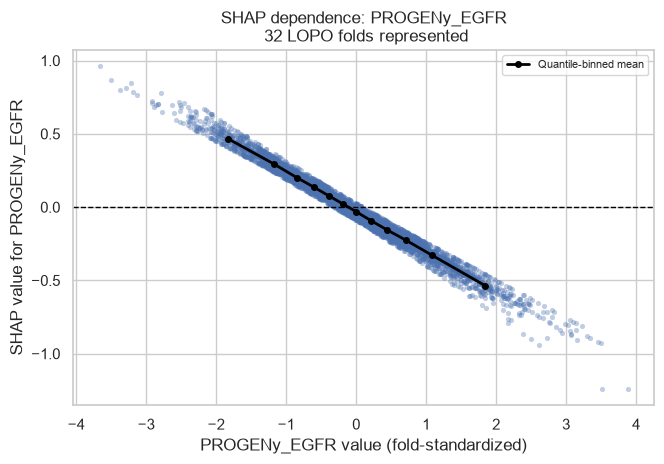

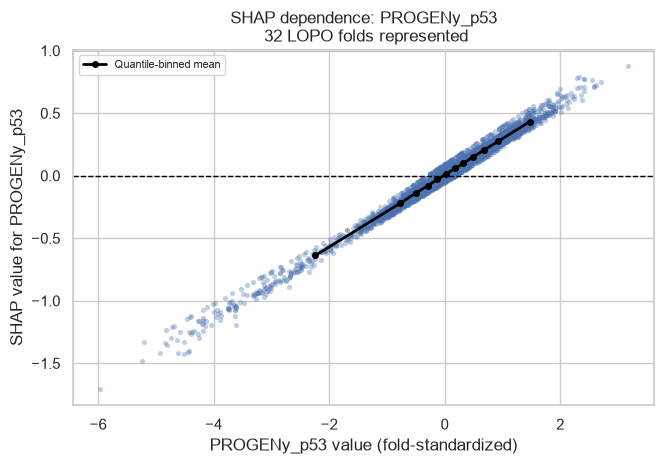

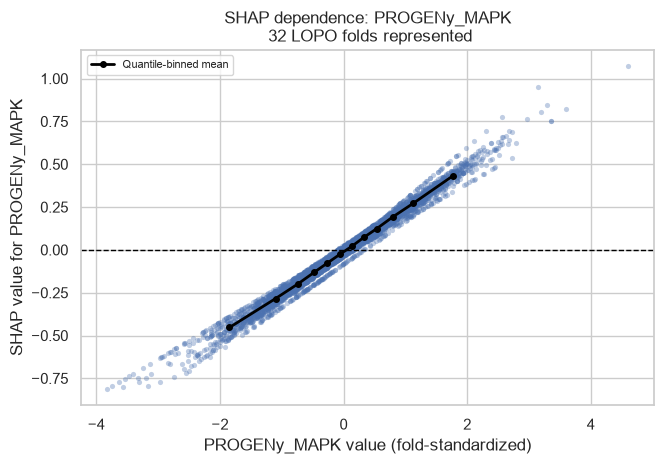

,feature,spearman_rho_feature_vs_shap,p_value_descriptive_only,direction,n_points,n_folds_with_shap
0,PROGENy_JAK-STAT,-0.983666,0.0,Higher value tends toward non-responder predic...,4800,32
1,PROGENy_NFkB,-0.996988,0.0,Higher value tends toward non-responder predic...,4800,32
2,PROGENy_TNFa,-0.996213,0.0,Higher value tends toward non-responder predic...,4800,32
3,PROGENy_EGFR,-0.992100,0.0,Higher value tends toward non-responder predic...,4800,32
4,PROGENy_p53,0.988559,0.0,Higher value tends toward responder prediction,4800,32
5,PROGENy_MAPK,0.994611,0.0,Higher value tends toward responder prediction,4800,32


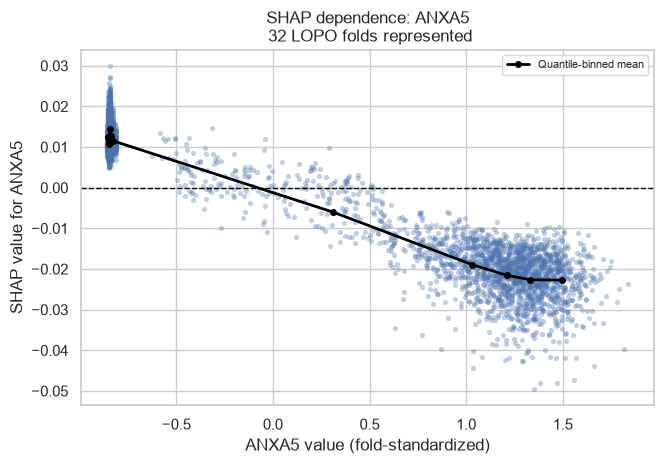

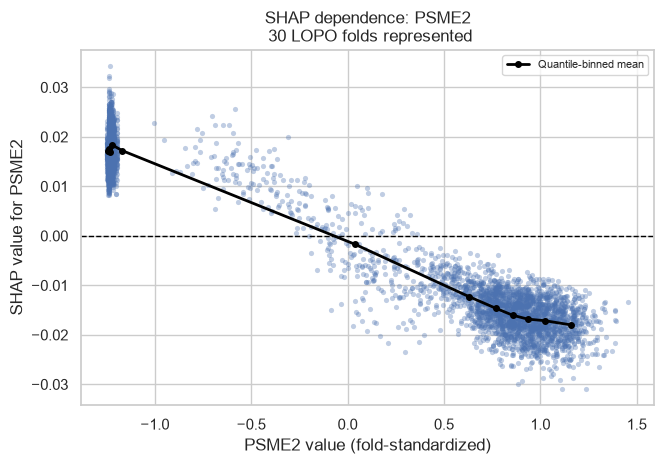

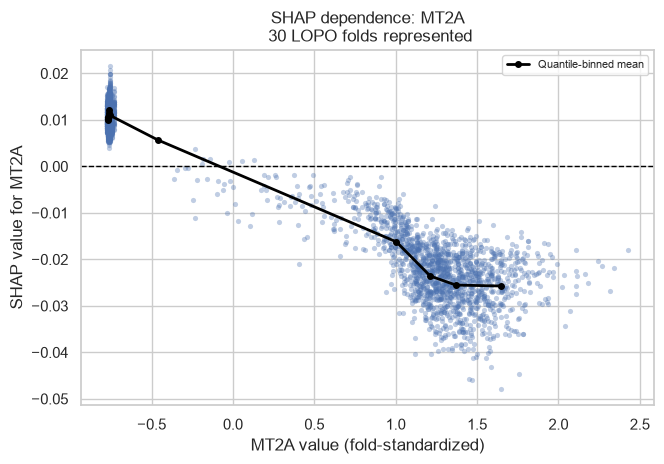

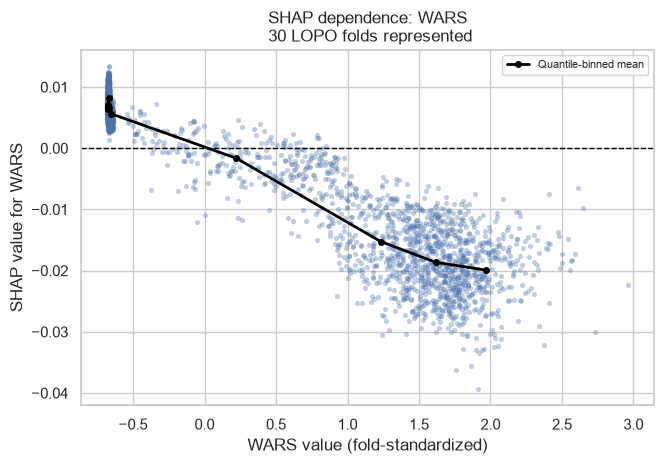

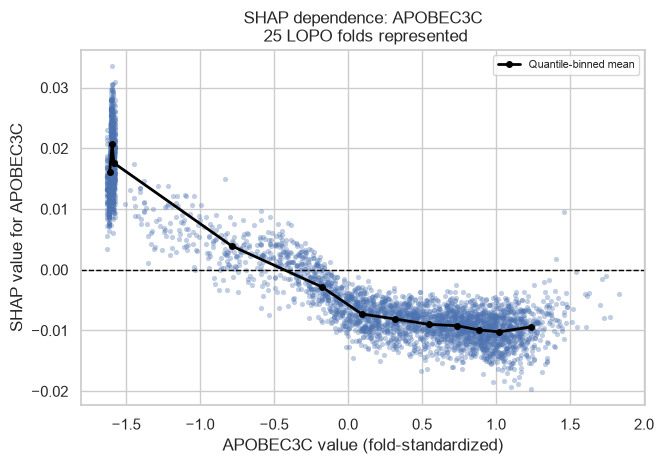

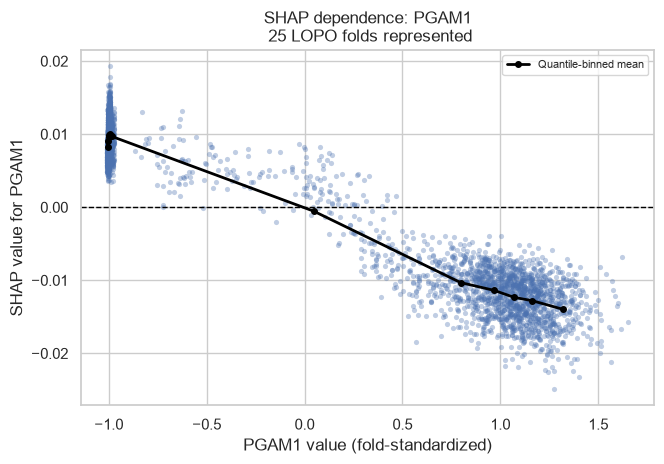

,feature,spearman_rho_feature_vs_shap,p_value_descriptive_only,direction,n_points,n_folds_with_shap
0,ANXA5,-0.753429,0.0,Higher value tends toward non-responder predic...,4800,32
1,PSME2,-0.839221,0.0,Higher value tends toward non-responder predic...,4500,30
2,MT2A,-0.681291,0.0,Higher value tends toward non-responder predic...,4500,30
3,WARS,-0.693692,0.0,Higher value tends toward non-responder predic...,4500,30
4,APOBEC3C,-0.828897,0.0,Higher value tends toward non-responder predic...,3750,25
5,PGAM1,-0.783288,0.0,Higher value tends toward non-responder predic...,3750,25


In [19]:
pathway_direction_summary = dependence_and_direction_summary(pathway_explanations,pathway_shap_points,)
gene_direction_summary = dependence_and_direction_summary( gene_explanations, gene_shap_points)

## Error Analysis: Discrimination, Calibration, Confusion, Misclassifications

In [20]:
def plot_discrimination_and_calibration(prediction_result):

    tag = prediction_result["tag"]
    data = prediction_result["sample_results"]

    y_true = data["true_label"].to_numpy(dtype=int)
    y_score = data["sample_score"].to_numpy(dtype=float)

    # Sample-level discrimination metrics.
    auc_value = roc_auc_score(y_true,y_score)
    ap_value = average_precision_score(y_true,y_score)
    fpr, tpr, _ = roc_curve(y_true,y_score)
    precision, recall, _ = precision_recall_curve(y_true,y_score)

    fig, axes = plt.subplots(1,3,figsize=(16, 4.6))

    # ROC curve
    axes[0].plot(fpr,tpr,linewidth=2,label=f"ROC-AUC = {auc_value:.3f}")
    axes[0].plot([0, 1],[0, 1],"--",color="grey")
    axes[0].set(xlabel="False-positive rate",ylabel="True-positive rate",title="ROC curve")
    axes[0].legend(loc="lower right")

    # Precision-Recall curve
    axes[1].plot(recall,precision,linewidth=2,label=f"Average precision = {ap_value:.3f}")
    axes[1].axhline(y_true.mean(),linestyle="--",color="grey",label=f"Prevalence = {y_true.mean():.3f}")
    axes[1].set(xlabel="Recall",ylabel="Precision",title="Precision-Recall curve")
    axes[1].legend(loc="lower left")

  
    # Calibration curve
    n_bins = min(5,max( 2, len(np.unique(y_score))))
    observed, predicted = calibration_curve(y_true,y_score,n_bins=n_bins,strategy="quantile")
    axes[2].plot(predicted,observed,marker="o",linewidth=2)
    axes[2].plot([0, 1],[0, 1],"--",color="grey")
    axes[2].set( xlabel="Mean predicted probability",ylabel="Observed responder fraction",title="Calibration curve")
    axes[2].set_xlim(0,1)
    axes[2].set_ylim(0,1)

    fig.suptitle( f"{tag.title()} held-out sample performance",fontweight="bold")
    plt.tight_layout()

    plt.savefig(TASKB5_FIGURES_DIR/ f"taskB5_{tag}_roc_pr_calibration.png",dpi=180,bbox_inches="tight")
    plt.show()

    return {"auc": auc_value,"average_precision": ap_value}

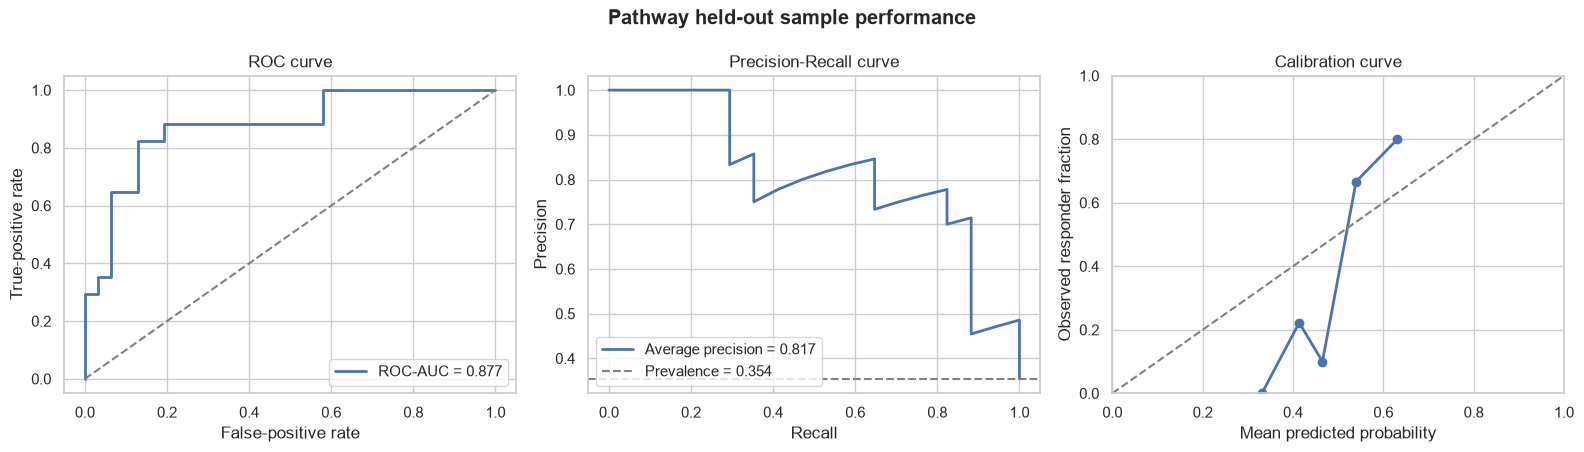

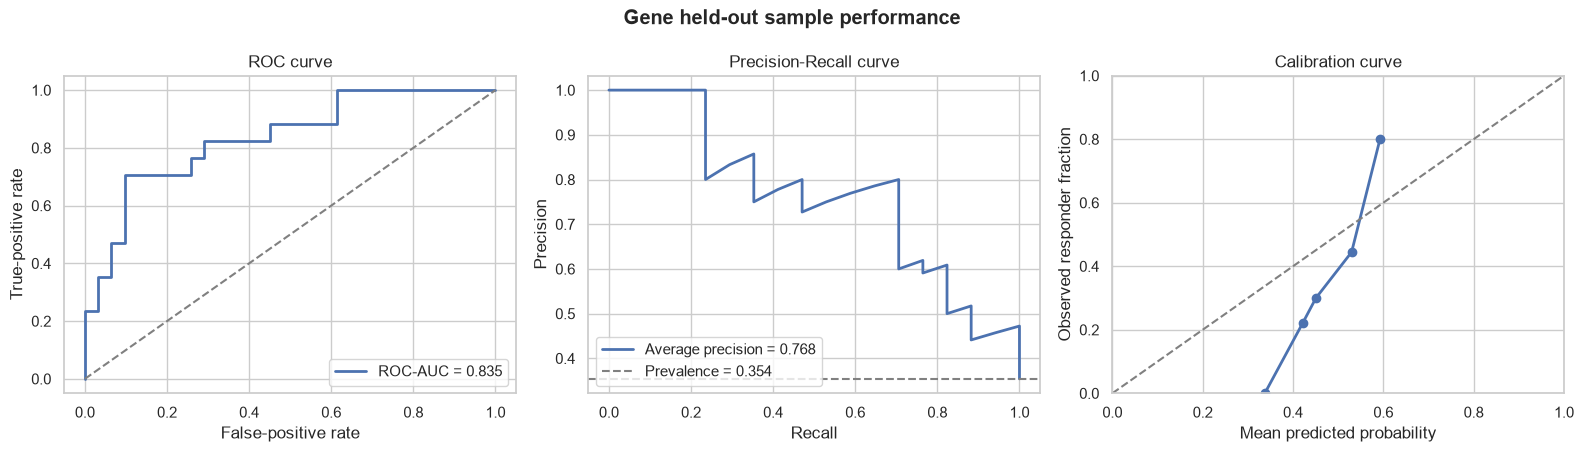

In [21]:
pathway_performance = plot_discrimination_and_calibration(pathway_predictions)
gene_performance = plot_discrimination_and_calibration( gene_predictions)

In [22]:
def plot_confusion_and_scores(prediction_result):

    tag = prediction_result["tag"]
    data = prediction_result["sample_results"].copy()

    # Confusion matrix using the fixed 0.5 decision threshold.
    matrix = confusion_matrix(data["true_label"],data["y_pred"],labels=[0, 1])

    fig, axes = plt.subplots(1,2,figsize=(15, 4.8),gridspec_kw={"width_ratios": [1, 2.4]})

    # Confusion matrix
    ConfusionMatrixDisplay(confusion_matrix=matrix,
                           display_labels=["Non-responder","Responder"]).plot( ax=axes[0],cmap="Blues",colorbar=False,values_format="d")

    axes[0].set_title("Confusion matrix\n""threshold = 0.5 (descriptive)")

    # Held-out sample scores
    ordered = (data.sort_values("sample_score").copy())
    ordered["response_label"] = (ordered["true_label"].map({0: "Non-responder", 1: "Responder"}))

    sns.barplot(data=ordered,x="sample_id",y="sample_score",hue="response_label",dodge=False,ax=axes[1],)
    axes[1].axhline(0.5,color="black",linestyle="--",linewidth=1)
    axes[1].set_title("Held-out sample scores ordered by prediction")
    axes[1].tick_params(axis="x",labelrotation=90,labelsize=7)
    axes[1].legend(title="True label",bbox_to_anchor=(1.02, 1),loc="upper left")

    fig.suptitle(f"{tag.title()} predictions at the 0.5 threshold",fontweight="bold")

    plt.tight_layout()
    plt.savefig(TASKB5_FIGURES_DIR/ f"taskB5_{tag}_confusion_and_ordered_scores.png",dpi=180,bbox_inches="tight")
    plt.show()

    return matrix

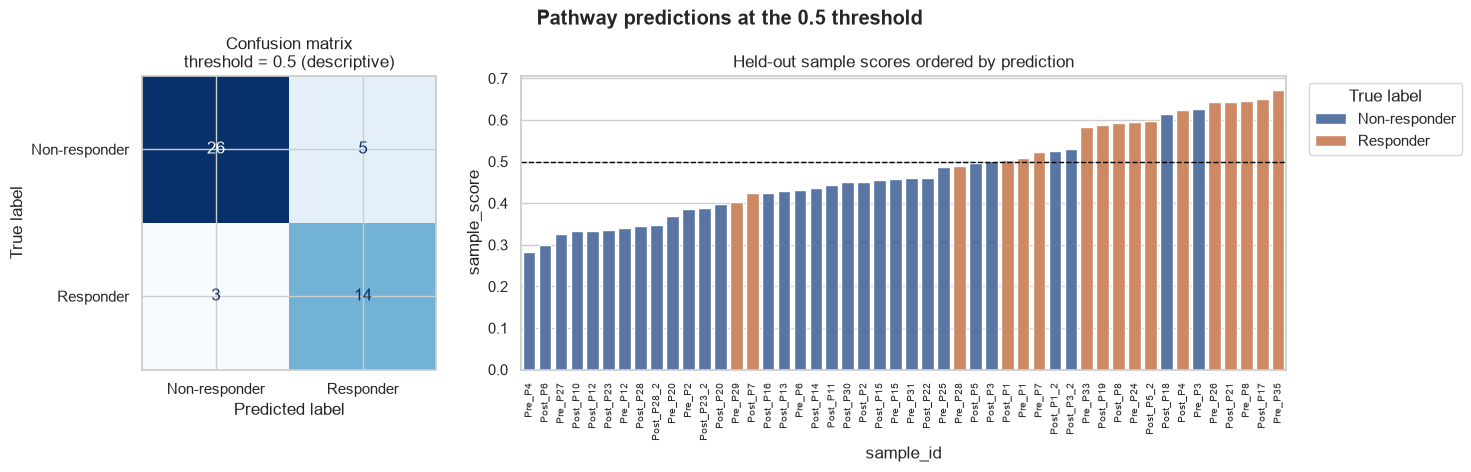

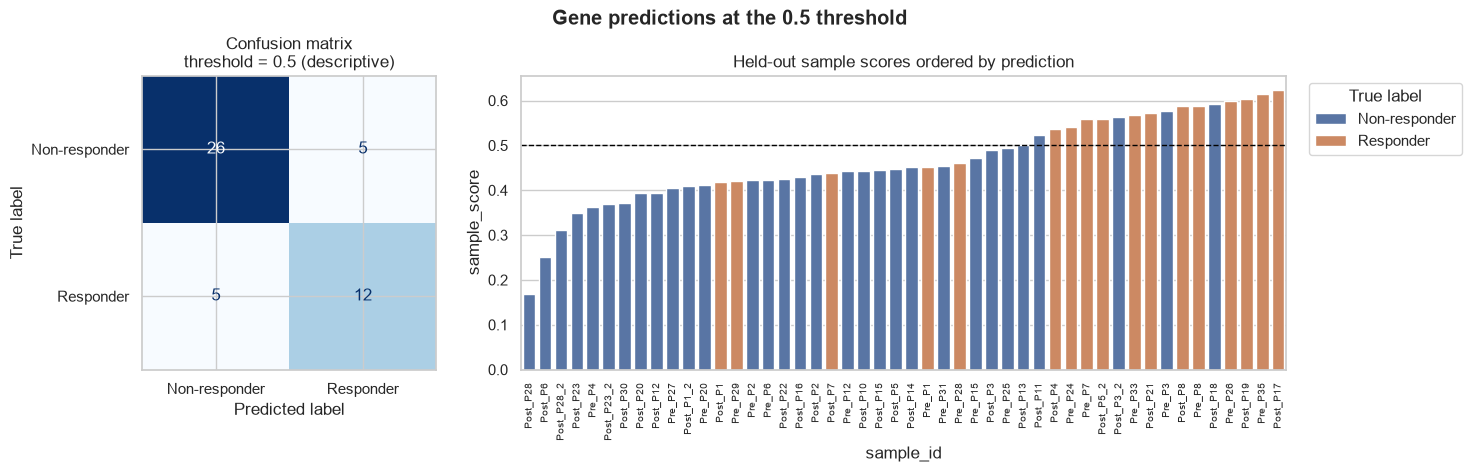

In [23]:
pathway_confusion = plot_confusion_and_scores(pathway_predictions)
gene_confusion = plot_confusion_and_scores(gene_predictions)

In [24]:
def inspect_errors(prediction_result):
    tag = prediction_result["tag"]
    data = prediction_result["sample_results"]

    # Misclassified samples, ordered by distance from the fixed 0.5 decision threshold.
    errors = (data[~data["correct"]].sort_values("confidence_margin",ascending=False).copy())
    false_positives = (errors[errors["error_type"] == "False positive" ].copy())
    false_negatives = (errors[errors["error_type"] == "False negative"].copy())

    # Samples closest to the 0.5 threshold.
    uncertain = ( data.sort_values("confidence_margin").copy())

    columns = [column for column in [ "patient_id", "sample_id", "true_label",
                                     "sample_score", "y_pred","error_type", "n_cells","confidence_margin"]
                                     if column in data.columns]

    print(f"\n{tag.title()}: {len(errors)} misclassified samples / {len(data)}")
    print(f"False positives: {len(false_positives)}")
    display(false_positives[columns])
    print(f"False negatives: {len(false_negatives)}")
    display(false_negatives[columns])
    print("Most uncertain samples:")
    display(uncertain[columns].head(10))

    errors.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_misclassified_samples.csv",index=False)
    false_positives.to_csv(TASKB5_OUTPUT_DIR/ f"taskB5_{tag}_false_positives.csv", index=False)
    false_negatives.to_csv( TASKB5_OUTPUT_DIR / f"taskB5_{tag}_false_negatives.csv", index=False)
    uncertain.to_csv(TASKB5_OUTPUT_DIR / f"taskB5_{tag}_uncertain_samples.csv", index=False )

    return errors

In [25]:
pathway_errors = inspect_errors(pathway_predictions)
gene_errors = inspect_errors(gene_predictions)


Pathway: 8 misclassified samples / 48
False positives: 5


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
33,P3,Pre_P3,0,0.625543,1,False positive,245,0.125543
13,P18,Post_P18,0,0.614371,1,False positive,357,0.114371
32,P3,Post_P3_2,0,0.530156,1,False positive,358,0.030156
1,P1,Post_P1_2,0,0.525224,1,False positive,353,0.025224
31,P3,Post_P3,0,0.501121,1,False positive,359,0.001121


False negatives: 3


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
30,P29,Pre_P29,1,0.403144,0,False negative,163,0.096856
44,P7,Post_P7,1,0.424338,0,False negative,231,0.075662
29,P28,Pre_P28,1,0.489048,0,False negative,337,0.010952


Most uncertain samples:


...

,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
13,P18,Post_P18,0,0.591330,1,False positive,357,0.091330
33,P3,Pre_P3,0,0.577050,1,False positive,245,0.077050
32,P3,Post_P3_2,0,0.562444,1,False positive,358,0.062444
4,P11,Post_P11,0,0.522676,1,False positive,313,0.022676
7,P13,Post_P13,0,0.501112,1,False positive,449,0.001112


False negatives: 5


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
0,P1,Post_P1,1,0.418251,0,False negative,291,0.081749
30,P29,Pre_P29,1,0.421715,0,False negative,163,0.078285
44,P7,Post_P7,1,0.437981,0,False negative,231,0.062019
2,P1,Pre_P1,1,0.452351,0,False negative,229,0.047649
29,P28,Pre_P28,1,0.460083,0,False negative,337,0.039917


Most uncertain samples:


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
7,P13,Post_P13,0,0.501112,1,False positive,449,0.001112
24,P25,Pre_P25,0,0.494743,0,Correct,371,0.005257
31,P3,Post_P3,0,0.490612,0,Correct,359,0.009388
4,P11,Post_P11,0,0.522676,1,False positive,313,0.022676
10,P15,Pre_P15,0,0.472263,0,Correct,304,0.027737
38,P4,Post_P4,1,0.536013,1,Correct,675,0.036013
29,P28,Pre_P28,1,0.460083,0,False negative,337,0.039917
23,P24,Pre_P24,1,0.540579,1,Correct,338,0.040579
35,P31,Pre_P31,0,0.455015,0,Correct,351,0.044985
2,P1,Pre_P1,1,0.452351,0,False negative,229,0.047649


c:\Users\mekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


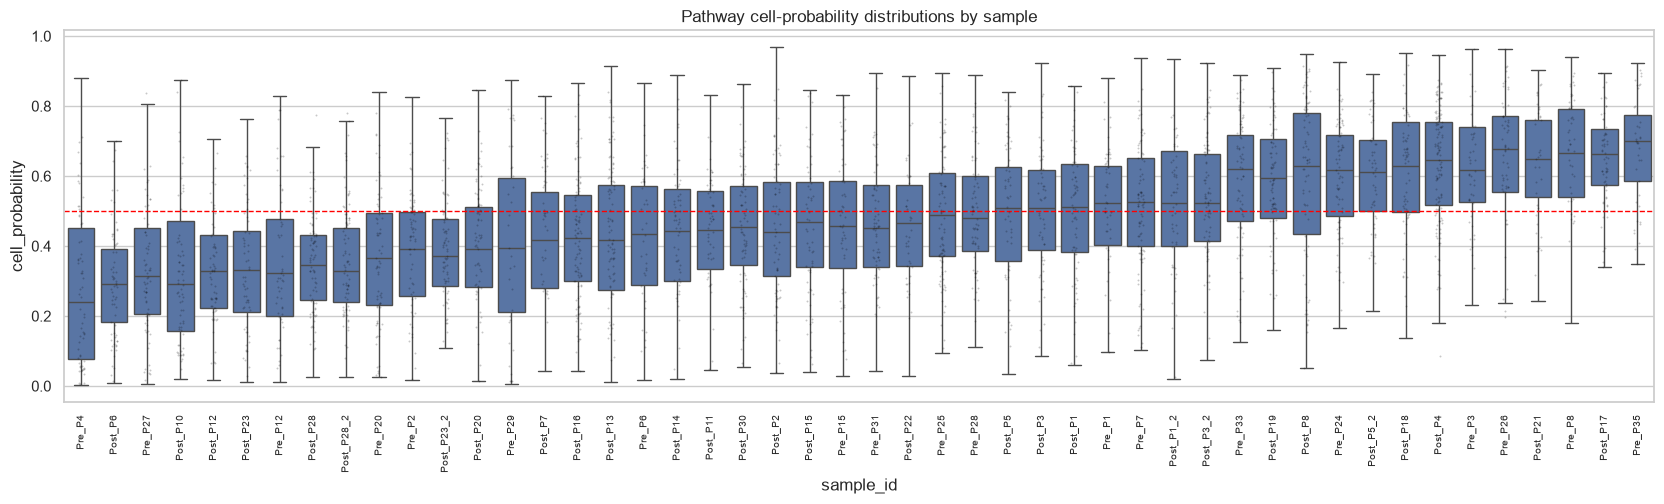

c:\Users\mekar\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


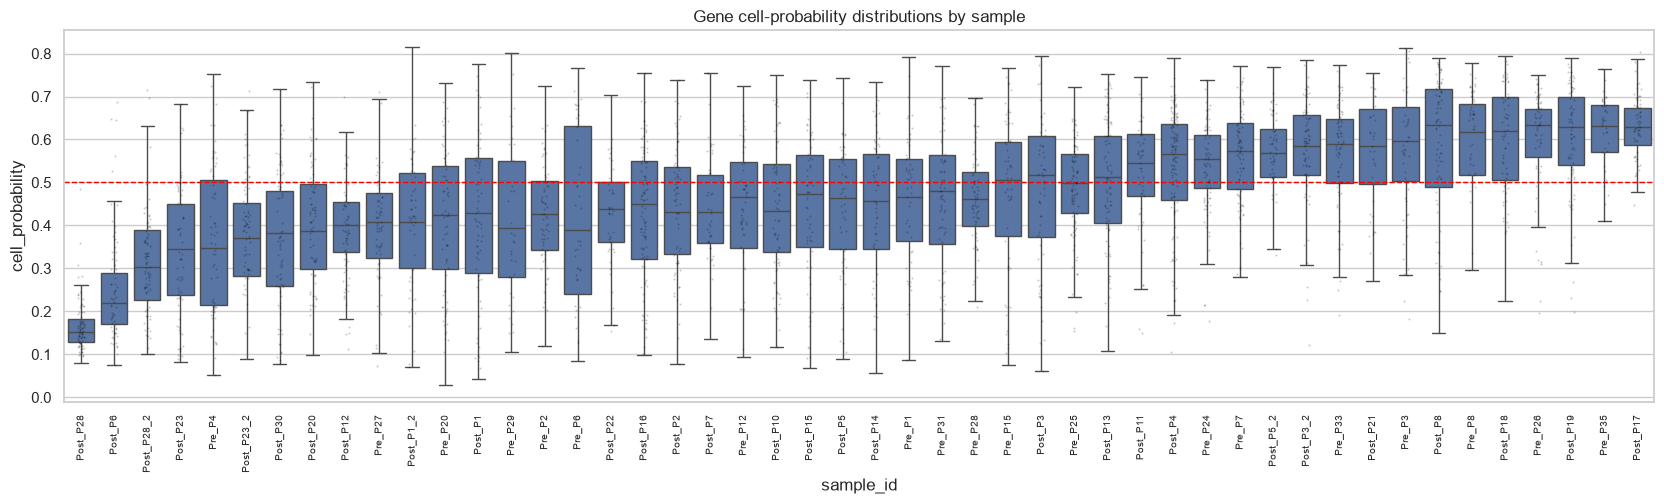

In [26]:
def plot_cell_probability_distributions(prediction_result):

    tag = prediction_result["tag"]
    cells_df = prediction_result["cell_predictions"]
    samples = prediction_result["sample_results"]

    # Ordering the samples according to their aggregatedheld-out sample-level prediction score.
    order = (samples.sort_values("sample_score")["sample_id"].astype(str).tolist())

    fig, ax = plt.subplots(figsize=(max(11, 0.35 * len(order)),5.2))

    # Showing the distribution of cell-level probabilities within each biological sample.
    sns.boxplot( data=cells_df, x="sample_id", y="cell_probability", order=order, showfliers=False, ax=ax)

    # Plotting a reproducible subset of cells to avoid overcrowding the figure.
    points = cells_df.sample(min(len(cells_df), 3000),random_state=SEED)
    sns.stripplot(data=points,x="sample_id",y="cell_probability",order=order,size=1.4,alpha=0.22,color="black",ax=ax)
    ax.axhline(0.5,color="red",linestyle="--",linewidth=1)
    ax.set_title(f"{tag.title()} cell-probability distributions by sample")
    ax.tick_params(axis="x",labelrotation=90,labelsize=7)


    plt.tight_layout()
    plt.savefig(TASKB5_FIGURES_DIR/ f"taskB5_{tag}_cell_probability_distributions.png",dpi=180,bbox_inches="tight")
    plt.show()


plot_cell_probability_distributions(pathway_predictions)
plot_cell_probability_distributions(gene_predictions)

## Compact Comparison Table

In [27]:
comparison = pd.DataFrame([{"representation": "Pathways","condition": BEST_PATHWAY_CONDITION,
                            "model": BEST_PATHWAY_MODEL, "sample_ROC_AUC": pathway_performance["auc"],
                            "average_precision": pathway_performance["average_precision"],
                            "misclassified_samples_at_0.5": len(pathway_errors),
                            "top_feature": (pathway_explanations["summary"].iloc[0]["feature"]),
                            "top_feature_selection_frequency": (pathway_explanations["summary"].iloc[0]["selection_frequency"])},
                            {"representation": "Genes","condition": BEST_GENE_CONDITION,
                             "model": BEST_GENE_MODEL,"sample_ROC_AUC": gene_performance["auc"],
                             "average_precision": gene_performance["average_precision"],
                             "misclassified_samples_at_0.5": len(gene_errors),
                             "top_feature": (gene_explanations["summary"].iloc[0]["feature"]),
                             "top_feature_selection_frequency": (gene_explanations["summary"].iloc[0]["selection_frequency"])}])

comparison.to_csv(TASKB5_OUTPUT_DIR / "taskB5_gene_vs_pathway_summary.csv",index=False)

display(comparison.round(4))

,representation,condition,model,sample_ROC_AUC,average_precision,misclassified_samples_at_0.5,top_feature,top_feature_selection_frequency
0,Pathways,B_Pathways,LogisticRegression,0.8767,0.8174,8,PROGENy_JAK-STAT,1.0
1,Genes,F_MI_Genes,RandomForest,0.8349,0.7675,10,ANXA5,1.0


---
# References

> [1] Pinhasi, A., Yizhak, K. Uncovering gene and cellular signatures of immune checkpoint response via machine learning and single-cell RNA-seq. *npj Precision Oncology* 9, 95 (2025). https://doi.org/10.1038/s41698-025-00883-z </br>
> [2] Lundberg, S.M. & Lee, S.-I. A Unified Approach to Interpreting Model Predictions. *NeurIPS* (2017). https://proceedings.neurips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions </br>
> [3] Chen, T. & Guestrin, C. XGBoost: A Scalable Tree Boosting System. *KDD* (2016). https://doi.org/10.1145/2939672.2939785 </br>
> [4] Davis, J. & Goadrich, M. The Relationship Between Precision-Recall and ROC Curves. *ICML* (2006). https://doi.org/10.1145/1143844.1143874
